In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.5 MB/s eta 0:00:00


In [4]:
!unzip -q /content/dataset.zip -d /content/dataset

In [5]:
from ultralytics import YOLO

# Use a slightly larger model
model = YOLO('yolov8s.pt')  # Switch to 'yolov8n.pt'

model.train(
    data='/content/dataset/data.yaml',   # Path to dataset config file in YOLO format
    epochs=50,                          # Increased number of training epochs
    imgsz=416,                           # Lower image resolution
    batch=4,                             # Batch size
    workers=2,                           # Number of dataloader workers
    freeze=10,                           # Freeze the first 10 layers (typically the backbone); only train detection head
    name='yolo_head_tuned_v1',           # Name of this training run
    project='/content/runs/train',       # Output directory for training logs and weights
    pretrained=True,                     # Use pretrained COCO weights

    # Enable data augmentation for better generalization
    mosaic=1.0,                          # Enable mosaic augmentation
    hsv_h=0.015,                         # Hue augmentation
    hsv_s=0.7,                           # Saturation augmentation
    hsv_v=0.4,                           # Value augmentation
    flipud=0.5,                          # Random vertical flip
    erasing=0.4,                         # Random erasing

    # Optional: Set initial learning rate
    lr0=0.005
)

Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_head_tuned_v12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

100%|██████████| 755k/755k [00:00<00:00, 95.7MB/s]

Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

Model summary: 129 layers, 11,137,922 parameters, 11,137,906 gradients, 28.7 GFLOPs

Transferred 349/355 items from pretrained weights
Freezing layer 'model.0.conv.weight'
Freezing layer 'model.0.bn.weight'
Freezing layer 'model.0.bn.bias'
Freezing layer 'model.1.conv.weight'
Freezing layer 'model.1.bn.weight'
Freezing layer 'model.1.bn.bias'
Freezing layer 'model.2.cv1.conv.weight'
Freezing layer 'model.2.cv1.bn.weight'
Freezing layer 'model.2.cv1.bn.bias'
Freezing layer 'model.2.cv2.conv.weight'
Freezing layer 'model.2.cv2.bn.weight'
Freezing layer 'model.2.cv2.bn.bias'
Freezing layer 'model.2.m.0.cv1.conv.weight'
Freezing layer 'model.2.m.0.cv1.bn.weight'
Freezing layer 'model.2.m.0.cv1.bn.bias'
Freezing layer 'model.2.m.0.cv2.conv.weight'
Freezing layer 'model.2.m.0.cv2.bn.weight'
Freezing layer 'model.2.m.0.cv2.bn.bias'
Freezing layer 'model.3.conv.weight'
Freezing layer 'model.3.bn.weight'
Freezing layer 'model.3.bn.bias'
Freezing layer 'model.4.cv1.conv.weight'
Freezing layer 'm

100%|██████████| 5.35M/5.35M [00:00<00:00, 348MB/s]


...

      50/50      2.95G     0.9078     0.7983      1.156          7        416: 100%|██████████| 1831/1831 [02:08<00:00, 14.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 263/263 [00:18<00:00, 14.16it/s]


                   all       2098      18916      0.569       0.45      0.494      0.344

50 epochs completed in 2.092 hours.
Optimizer stripped from /content/runs/train/yolo_head_tuned_v12/weights/last.pt, 22.5MB
Optimizer stripped from /content/runs/train/yolo_head_tuned_v12/weights/best.pt, 22.5MB

Validating /content/runs/train/yolo_head_tuned_v12/weights/best.pt...
Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 263/263 [00:16<00:00, 16.13it/s]


                   all       2098      18916      0.574      0.438      0.498      0.346
         BIODEGRADABLE        676      13637      0.816      0.423      0.595       0.33
             CARDBOARD        438       1292      0.702      0.484      0.589      0.439
                 GLASS        805       2380      0.866      0.629      0.751      0.577
                 METAL        398       1360      0.686      0.518      0.601      0.411
                 PAPER         15         33     0.0273     0.0606      0.067     0.0662
               PLASTIC         91        214      0.344      0.516      0.388      0.253
Speed: 0.1ms preprocess, 2.2ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/train/yolo_head_tuned_v12


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e5e1f993210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [8]:
# Load the best trained model
model = YOLO('/content/runs/train/yolo_head_tuned_v12/weights/best.pt')

# Perform evaluation on the test set with Test-Time Augmentation (TTA) enabled
metrics = model.val(
    data='/content/dataset/data.yaml',
    split='test',
    augment=True,
    project='runs/detect',
    name='head_tuned_test_eval'
)

# Print key evaluation metrics
print("mAP50:", metrics.box.map50)         # Mean Average Precision at IoU threshold 0.5
print("mAP50-95:", metrics.box.map)        # Mean Average Precision averaged over IoU thresholds from 0.5 to 0.95
print("Precision (mean):", metrics.box.mp) # Mean precision across all classes
print("Recall (mean):", metrics.box.mr)    # Mean recall across all classes
print("Per-class AP@50:", metrics.box.ap50)   # AP@0.5 for each class
print("Per-class AP@50-95:", metrics.box.ap)  # AP@0.5–0.95 for each class



Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 545.9±305.4 MB/s, size: 21.6 KB)


val: Scanning /content/dataset/test/labels... 1042 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1042/1042 [00:00<00:00, 2364.75it/s]

val: New cache created: /content/dataset/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 66/66 [00:16<00:00,  4.08it/s]


                   all       1042       3563      0.504      0.443      0.434      0.332
         BIODEGRADABLE          8         49      0.112      0.163      0.077      0.041
             CARDBOARD         11         20      0.118        0.3     0.0891     0.0658
                 METAL        172        533      0.708      0.688      0.691      0.586
                 PAPER        515       1376      0.822      0.506      0.639      0.507
               PLASTIC        354       1585      0.759      0.557      0.672       0.46
Speed: 0.2ms preprocess, 10.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/head_tuned_test_eval
mAP50: 0.4337302584871054
mAP50-95: 0.33198902752004306
Precision (mean): 0.5037583417318481
Recall (mean): 0.4428788943908547
Per-class AP@50: [   0.077041    0.089052      0.6913     0.63882     0.67243]
Per-class AP@50-95: [   0.041046    0.065847     0.58634     0.50709     0.45963]


In [9]:
from google.colab import files
files.download('/content/runs/train/yolo_head_tuned_v12/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

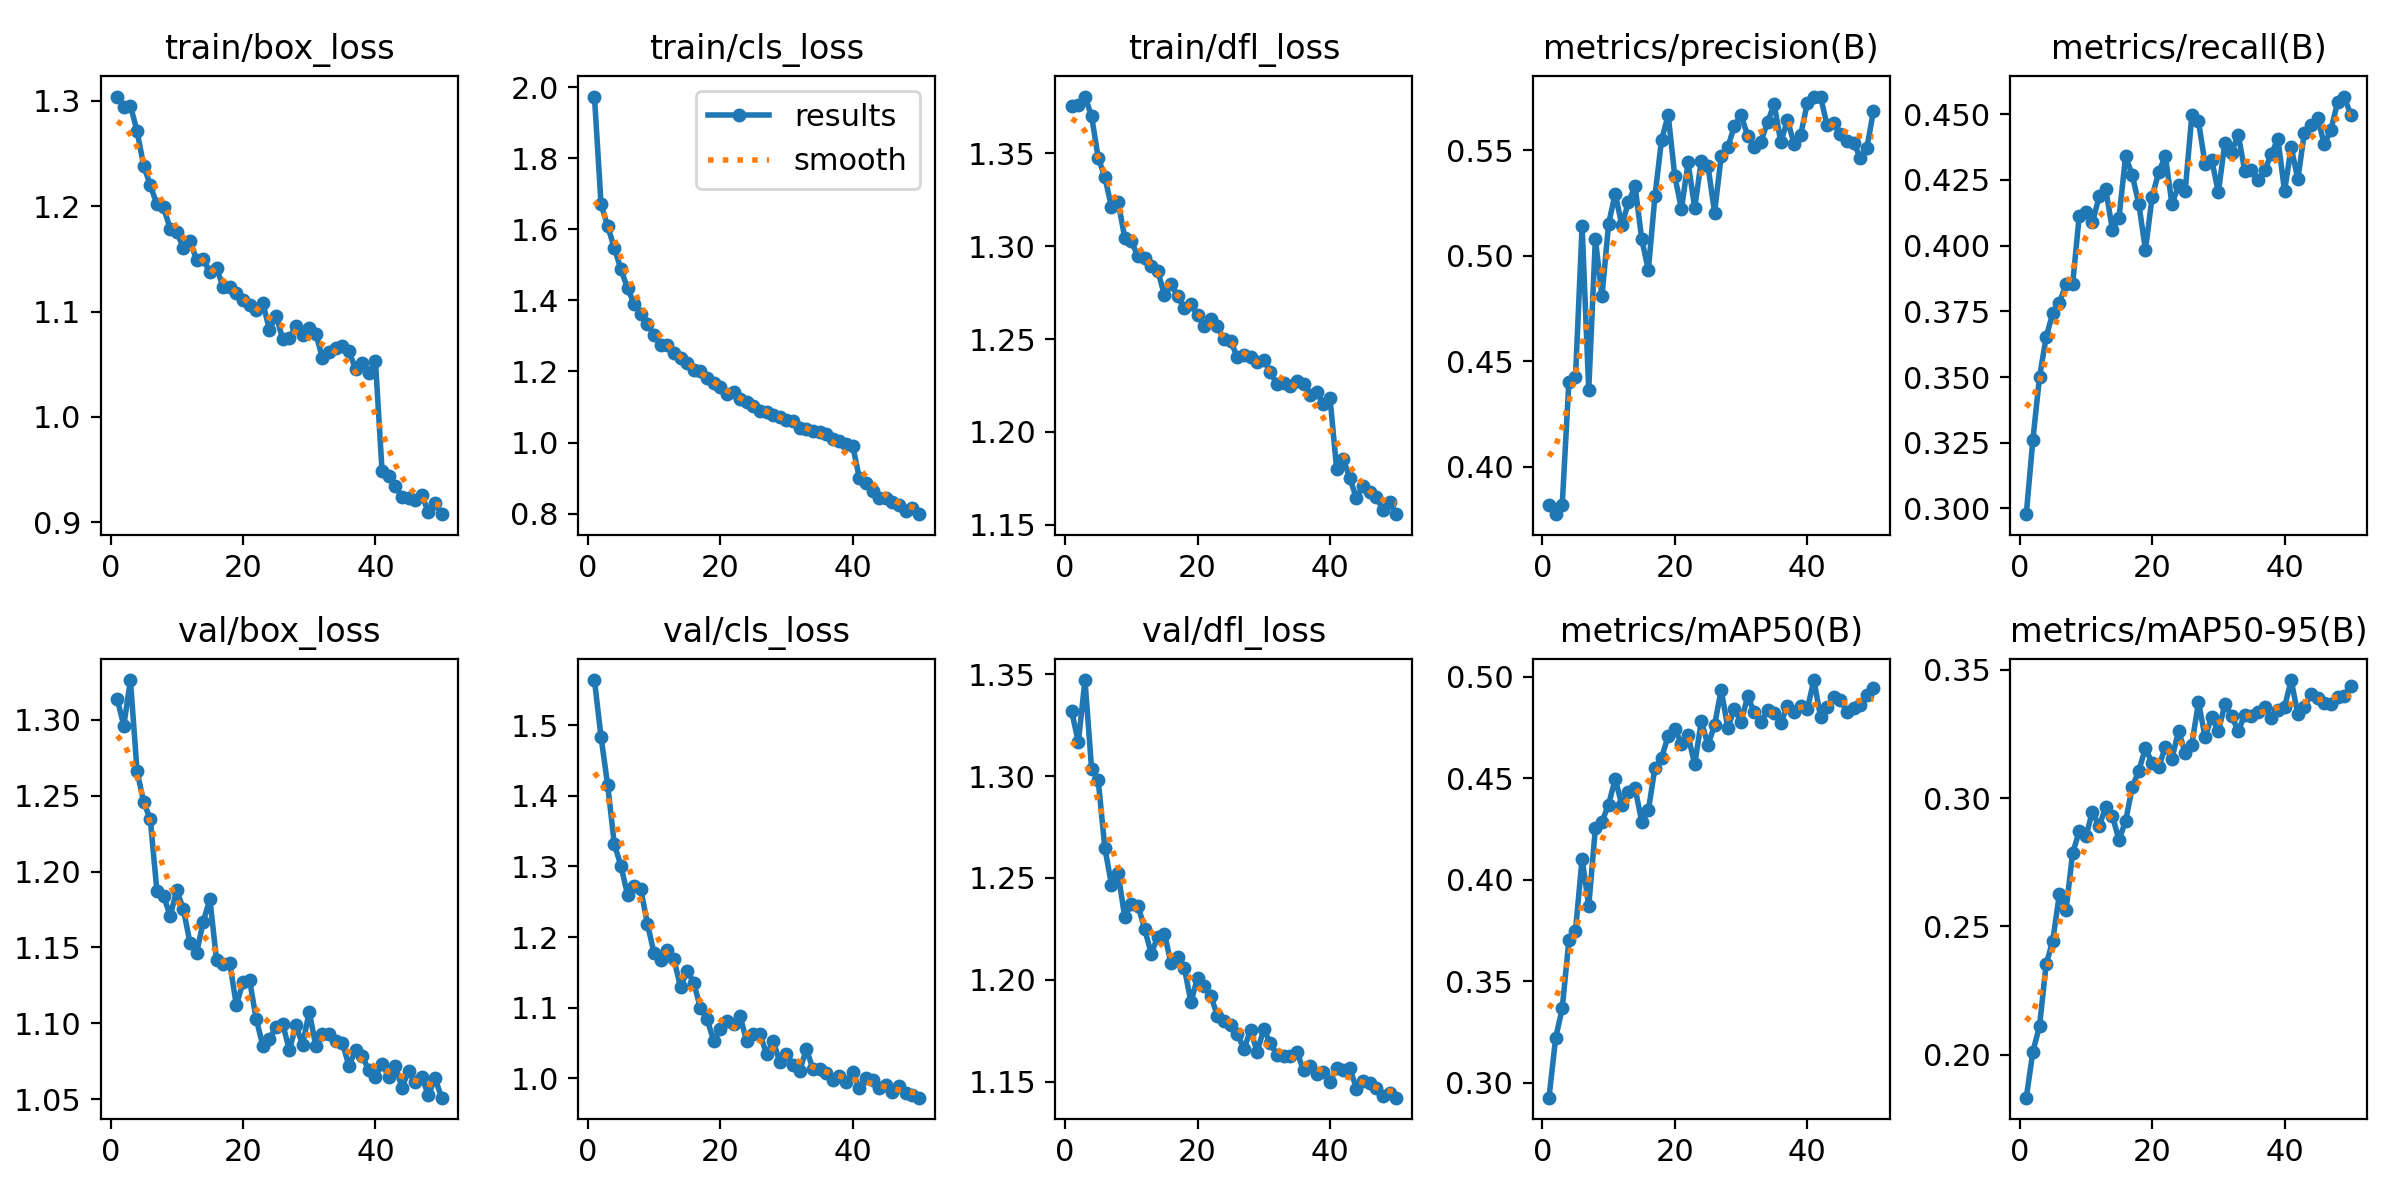

In [10]:
import pandas as pd
from IPython.display import Image

# Load training metrics
df = pd.read_csv('/content/runs/train/yolo_head_tuned_v12/results.csv')
df.tail()

# Plot training curves (loss, mAP)
Image(filename='/content/runs/train/yolo_head_tuned_v12/results.png')


0: 416x416 1 CARDBOARD, 1 METAL, 8.6ms
1: 416x416 1 METAL, 8.6ms
2: 416x416 2 METALs, 8.6ms
3: 416x416 1 METAL, 8.6ms
4: 416x416 2 METALs, 8.6ms
Speed: 1.0ms preprocess, 8.6ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/predict_metal


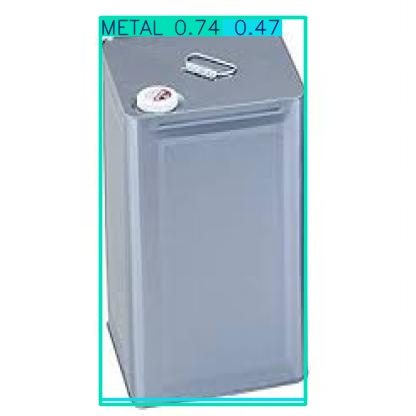

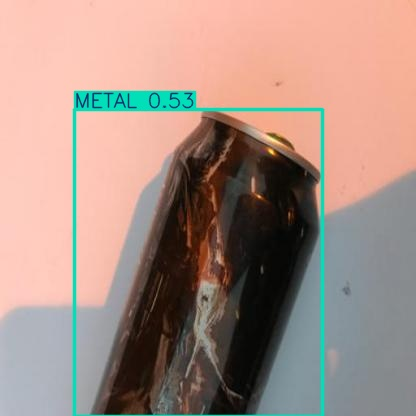

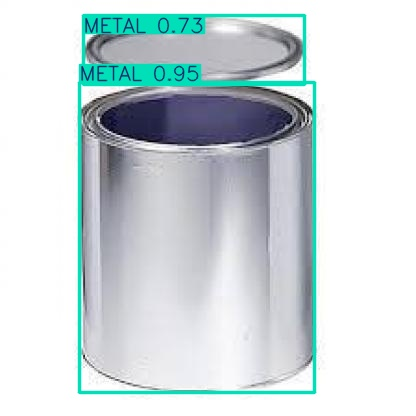

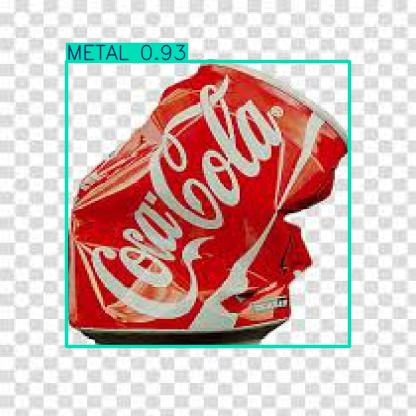

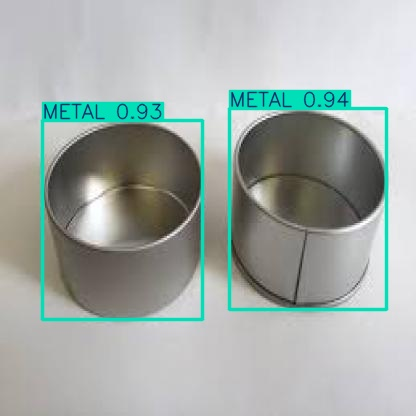

In [11]:
from ultralytics import YOLO
from IPython.display import display, Image

# Load the trained YOLOv8 model
model = YOLO('/content/runs/train/yolo_head_tuned_v12/weights/best.pt')

# List of 5 test image paths to perform inference on
image_paths = [
    '/content/dataset/test/images/metal1000_jpg.rf.f972491130c59d3bff7e97b22e8e2980.jpg',
    '/content/dataset/test/images/metal1005_jpg.rf.d736ab336e8fa92ce57727666e624259.jpg',
    '/content/dataset/test/images/metal100_jpg.rf.8605f3d87c15f6f37575fa2907d5bc6c.jpg',
    '/content/dataset/test/images/metal1014_jpeg.rf.7c66a5a281d17fde9891d5777c496391.jpg',
    '/content/dataset/test/images/metal1016_jpg.rf.e9045ffa8d93980005dca0adcce9f187.jpg'
]

# Run inference and save predictions to the 'predict_metal' folder
results = model.predict(
    source=image_paths,          # Input images
    save=True,                   # Save annotated predictions
    project='runs/detect',       # Root directory for saving results
    name='predict_metal',        # Subfolder name
    conf=0.25                    # Confidence threshold
)

# Display the prediction results inline
for img_path in image_paths:
    filename = img_path.split('/')[-1]
    result_path = f'/content/runs/detect/predict_metal/{filename}'
    display(Image(filename=result_path))
